In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xso

In [2]:
from phydra.models import NPxZxSizeBased

In [3]:
def calculate_sizes(size_min, size_max, num):
    """initializes log spaced array of sizes from ESD size range"""
    numbers = np.array([i for i in range(num)])
    sizes = (np.log(size_max) - np.log(size_min))* numbers / (num-1) + np.log(size_min)
    return np.exp(sizes)

def calculate_zoo_I0(sizes):
    """initializes allometric Zooplankton ingestion rate based on array of sizes (ESD)"""
    return 26 * sizes ** -0.4

def calculate_phyto_mu0(sizes):
    """initializes allometric Phytoplankton maximum growth rate based on array of sizes (ESD)
    allometric relationships are taken from meta-analyses of lab data"""
    return 2.6 * sizes ** -0.45

def calculate_phyto_ks(sizes):
    """initializes allometric Phytoplankton half-saturation constant based on array of sizes (ESD)"""
    return sizes * .1

def calculate_opt_size(sizes):
    """Calculating optimal prey size from Zooplankton sizes"""
    return 0.65 * sizes ** 0.56


def init_phiP(phytosize, zoopreyoptsize):
    """creates matrix of feeding preferences [P...P10] for each [Z]"""
    phiP = np.array([[np.exp(-((np.log10(xpreyi) - np.log10(xpreyoptj)) / 0.25) ** 2)
                      for xpreyi in phytosize] for xpreyoptj in zoopreyoptsize])
    return phiP

In [45]:
# number size classes of phytoplankton and zooplankotn
PZ_num = 40

# create initial biomass
phyto_init = np.tile(.5/PZ_num, (PZ_num))
zoo_init = np.tile(.1/PZ_num, (PZ_num))

# calculate log-spaced size classes from ranges and total number
phyto_sizes = calculate_sizes(1.,20.,PZ_num)
zoo_sizes = 2.16 * phyto_sizes **1.79 

# ingestion
zoo_I0 = calculate_zoo_I0(zoo_sizes)

# growth
phyto_mu0 = calculate_phyto_mu0(phyto_sizes)
phyto_ks = calculate_phyto_ks(phyto_sizes)

# grazing
preyoptsize = calculate_opt_size(zoo_sizes)
phiP = init_phiP(phyto_sizes, preyoptsize)

In [46]:
BASE_INPUT_VARS={
        # State variables
        'Nutrient':{'value_label':'N','value_init':1.},
        'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
        'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
    
        # Flows:
        'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
    
        # Growth
        'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

        # Grazing
        'Grazing':{'resource':'P', 'consumer':'Z',
                   'Imax':zoo_I0, 'KsZ':3., 'phiP':phiP},
        'GGE':{'grazed_resource':'P', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
               'epsilon':1./3., 'f_eg':1./3.},
    
        # Mortality
        'PhytoMortality':{'var':'P', 'rate':0.1*phyto_mu0},
        'ZooMortality':{'var':'Z', 'rate':1.},

        # Forcings
        'N0':{'forcing_label':'N0', 'value':1.},
}

In [47]:
model = NPxZxSizeBased
        
model_setup_stability = xso.setup(
    solver='stability', 
    model=model,
    time=[0,1],
    input_vars=BASE_INPUT_VARS
)

model_setup_ivp = xso.setup(
    solver='solve_ivp', 
    model=model,
    time=np.arange(0,365*10),
    input_vars=BASE_INPUT_VARS
)


/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/xsimlab/xr_accessor.py:229: FutureWarning: variable 'clock' with name matching its dimension will not be automatically converted into an `IndexVariable` object in the future.
  xr_var = as_variable(data, name=dim)


In [48]:
with NPxZxSizeBased:
        model_out = model_setup_ivp.xsimlab.run()

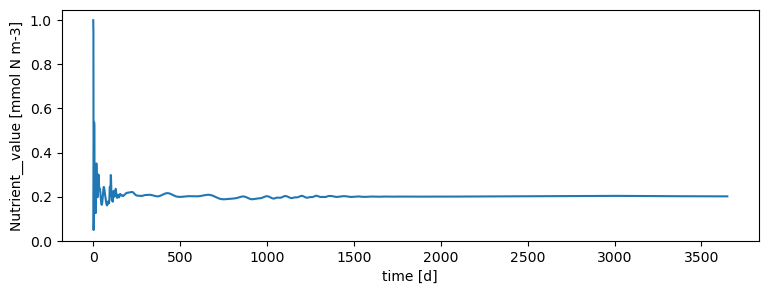

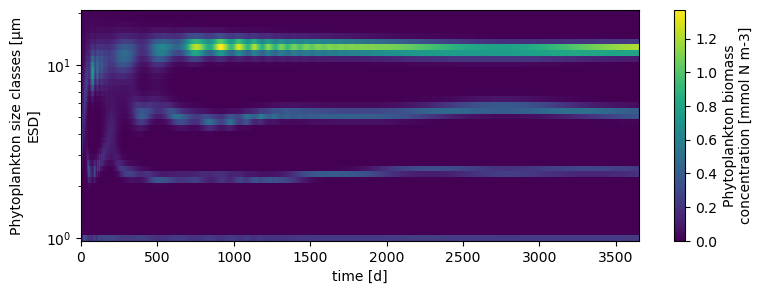

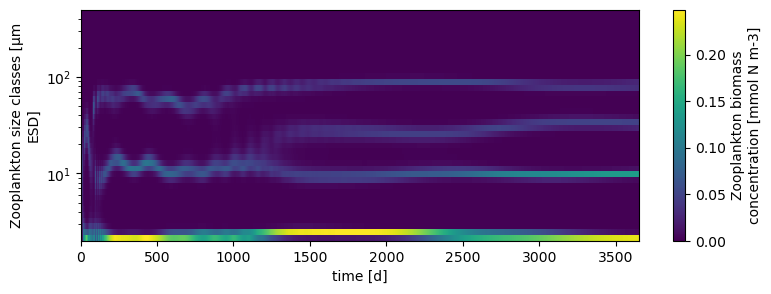

In [49]:
# let's get a quick overivew:

# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)
# zooplankton
model_out.Zooplankton__biomass.plot(yscale='log', aspect=3, size=3)

In [50]:
# Select variables and get the mean of the last 1000 time steps
mean_out = model_out[['Nutrient__value','Phytoplankton__biomass', 'Zooplankton__biomass']] \
                         .isel(time=slice(-1000, None)) \
                         .mean(dim='time')


mean_out

<xarray.Dataset> Size: 1kB
Dimensions:                 (phyto: 40, zoo: 40)
Coordinates:
  * phyto                   (phyto) float64 320B 1.0 1.08 1.166 ... 18.52 20.0
  * zoo                     (zoo) float64 320B 2.16 2.478 2.844 ... 401.4 460.6
Data variables:
    Nutrient__value         float64 8B 0.2025
    Phytoplankton__biomass  (phyto) float64 320B 0.2371 1.323e-137 ... 7.43e-14
    Zooplankton__biomass    (zoo) float64 320B 0.2039 0.04437 ... 0.0 0.0

In [51]:
model_setup_ivp_2 = model_setup_ivp.xsimlab.update_vars(model=model,
                             input_vars={'Nutrient__value_init':mean_out.Nutrient__value.values,
                                       'Phytoplankton__biomass_init':mean_out.Phytoplankton__biomass.values,
                                       'Zooplankton__biomass_init':mean_out.Zooplankton__biomass.values})



In [52]:
with NPxZxSizeBased:
        model_out = model_setup_ivp_2.xsimlab.run()

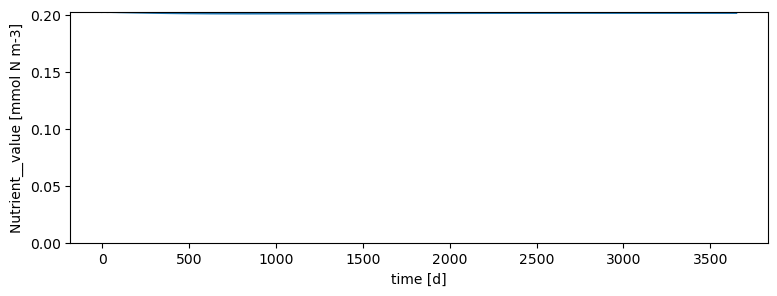

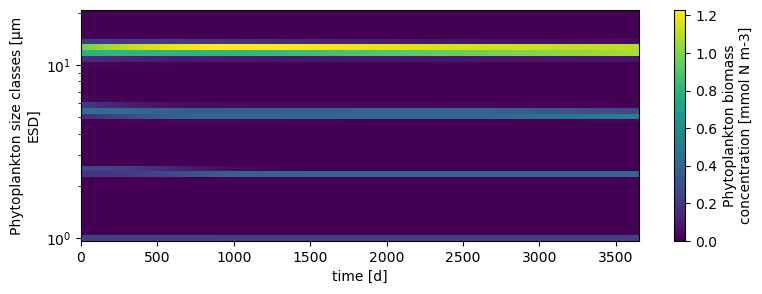

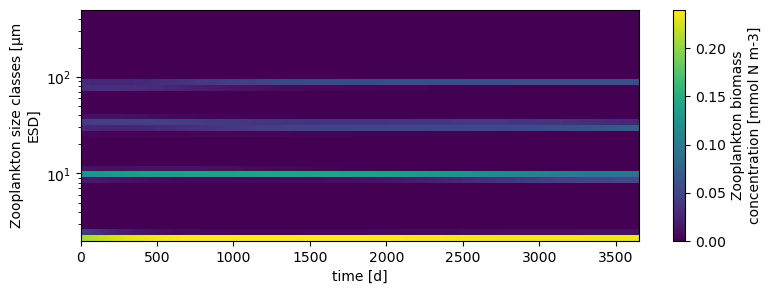

In [53]:
# let's get a quick overivew:

# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)
# zooplankton
model_out.Zooplankton__biomass.plot(yscale='log', aspect=3, size=3)

In [54]:
with NPxZxSizeBased:
        model_out_fsolve = model_setup_stability.xsimlab.update_vars(input_vars={'Nutrient__value_init':mean_out.Nutrient__value.values,
                                       'Phytoplankton__biomass_init':mean_out.Phytoplankton__biomass.values,
                                       'Zooplankton__biomass_init':mean_out.Zooplankton__biomass.values}
                                                             ).xsimlab.run()

[INFO] Initial state dimension: 81
[INFO] Initial state: [2.02493065e-001 2.37112434e-001 1.32276909e-137 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 7.00000000e-153
 7.14311478e-103 5.76308840e-060 1.50580613e-028 1.33291595e-009
 1.86539400e-001 2.46550438e-001 1.98573609e-005 3.15392123e-010
 1.90551359e-013 4.18574596e-014 2.17573304e-012 2.95290089e-009
 7.26358003e-006 3.81663653e-003 1.46154166e-001 4.46272017e-001
 2.15769330e-001 3.20216982e-002 3.23999236e-003 5.13301059e-004
 2.30618372e-004 3.66969065e-004 1.77602144e-003 1.67444934e-002
 1.62782716e-001 7.85641062e-001 9.62316030e-001 1.97019037e-001
 6.34914382e-003 4.22738105e-005 9.08947557e-008 9.70854469e-011
 7.42952629e-014 2.03890202e-001 4.43714219e-002 1.48536191e-007
 3.86429395e-014 3.48679442e-019 3.89036246e-021 1.03957827e-019
 1.07939211e-015 1.68543910e-010 1.10524368e-005 1.59686778e-002
 1.21147188e-001 1.08196532e-002 2.40966525e-004 1.43841175e-005
 6.19211764e-006 2.21375343e-005 

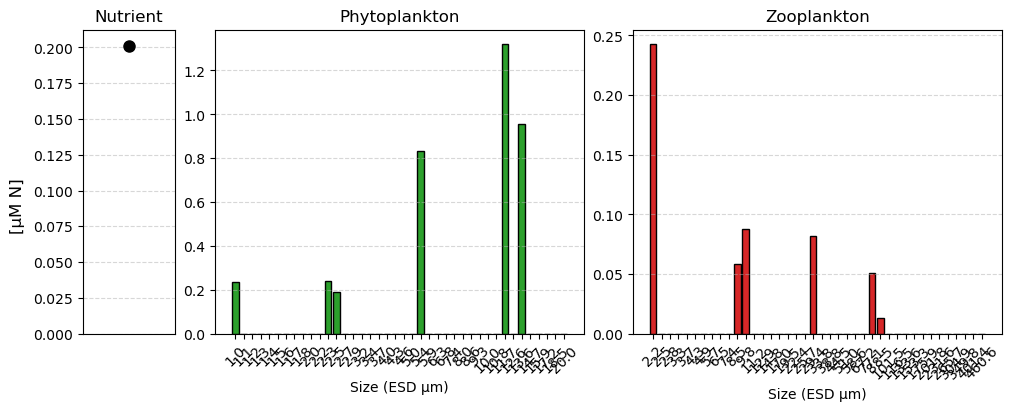

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Select the steady state (time=1)
ds_ss = model_out_fsolve.isel(time=-1)

# Create figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True, 
                         gridspec_kw={'width_ratios': [1, 4, 4]})

# Shared Y-axis label
fig.supylabel('[µM N]')

# --- 1. Nutrient (Dot) ---
axes[0].plot(0, ds_ss.Nutrient__value, 'o', color='k', markersize=8)
axes[0].set_title('Nutrient')
axes[0].set_ylim(bottom=0)
axes[0].set_xticks([])
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- 2. Phytoplankton (Bar Plot) ---
x_phyto = np.arange(len(ds_ss.phyto))
axes[1].bar(x_phyto, ds_ss.Phytoplankton__biomass, color='tab:green', width=0.8, edgecolor='black')

axes[1].set_title('Phytoplankton')
axes[1].set_ylim(bottom=0)
axes[1].set_xticks(x_phyto)
axes[1].set_xticklabels([f"{x:.1f}" for x in ds_ss.phyto.values], rotation=45)
axes[1].set_xlabel('Size (ESD µm)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- 3. Zooplankton (Bar Plot) ---
x_zoo = np.arange(len(ds_ss.zoo))
axes[2].bar(x_zoo, ds_ss.Zooplankton__biomass, color='tab:red', width=0.8, edgecolor='black')

axes[2].set_title('Zooplankton')
axes[2].set_ylim(bottom=0)
axes[2].set_xticks(x_zoo)
axes[2].set_xticklabels([f"{x:.1f}" for x in ds_ss.zoo.values], rotation=45)
axes[2].set_xlabel('Size (ESD µm)')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

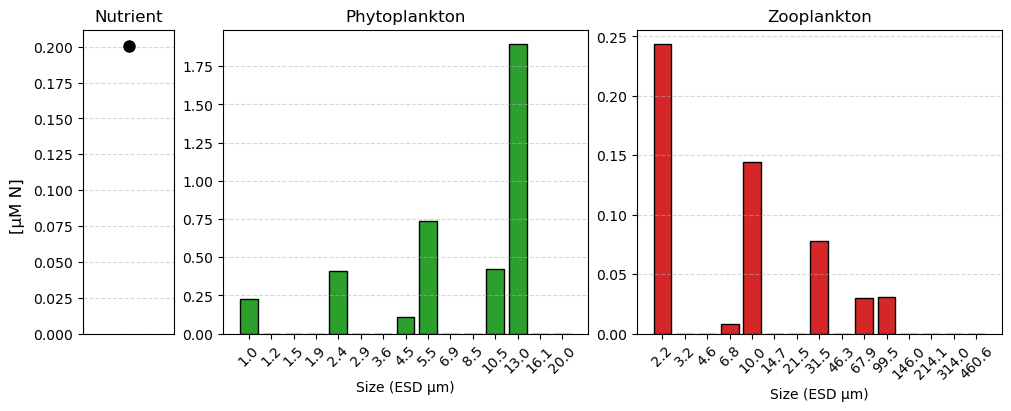

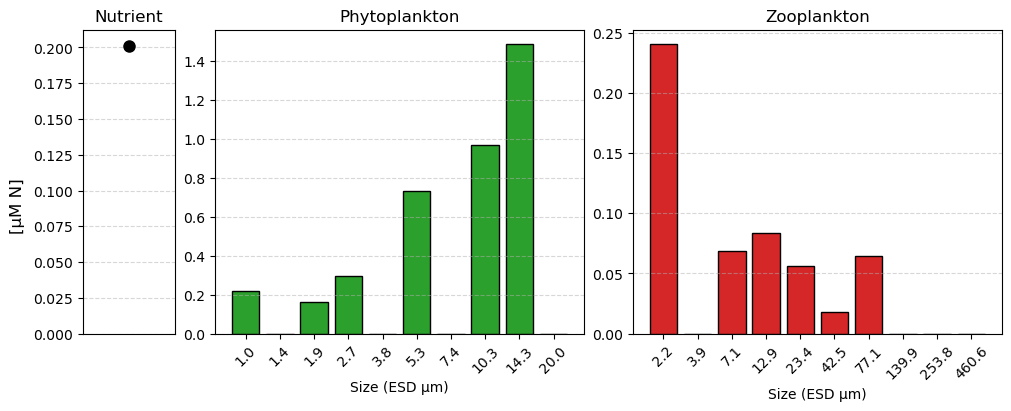